In [1]:
import os

os.environ['HTTP_PROXY'] = 'http://127.0.0.1:10808'
os.environ['HTTPS_PROXY'] = 'http://127.0.0.1:10808'
os.environ['NO_PROXY'] = 'localhost,127.0.0.1'

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
import kagglehub

In [ ]:

# Download latest version
path = kagglehub.dataset_download("austinreese/craigslist-carstrucks-data")

print("Path to dataset files:", path)

/home/miad/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/miad/.cache/kagglehub/datasets/austinreese/craigslist-carstrucks-data/versions/10


In [3]:
for f in os.listdir(path):
    print(f)

vehicles.csv


In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)
csv_path = os.path.join(path, "vehicles.csv")
df = pd.read_csv(csv_path)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [6]:
df = df.drop(columns=["id", "url","region_url","VIN", "description", "image_url"])
# dropping county since it is all null
# size and posting_datecause it has a lot of null
# paint does not have corr
df = df.drop(columns=["county", "lat", "long", "region", "paint_color", "size", "posting_date", "title_status"])

# dropping rows with null value in price, year, model, manufacturer
df = df.dropna(subset=['price', 'year', 'model', 'manufacturer'])

In [ ]:

# Fill missing categorical features with 'unknown'
for col in ['condition', 'drive', 'type', 'fuel']:
    df[col] = df[col].fillna('unknown')

# Fill missing transmission with most common value
df['transmission'] = df['transmission'].fillna(df['transmission'].mode()[0])

# Clean cylinders (convert text like '6 cylinders' → 6)
df['cylinders'] = df['cylinders'].str.extract(r'(\d+)').astype(float)
df['cylinders'] = df['cylinders'].fillna(df['cylinders'].median())

df = df[df["odometer"].between(0, 350_000)]
df = df[df["price"].between(300, 80_000)]
df = df[df["year"] > 1980]

In [8]:
# convert objects to category
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype('category')

In [9]:
#    keep=False marks ALL rows that are part of any duplicate set as True.
all_duplicates_mask = df.duplicated(keep=False)

all_duplicate_rows_df = df[all_duplicates_mask]

# 3. Sort them to see them grouped together
print("All rows that are part of a duplicate set:")
display(all_duplicate_rows_df.sort_values(by=['manufacturer', 'model', 'year', 'price']))

print(f"Shape before dropping duplicates: {df.shape}")

df = df.drop_duplicates()

print(f"Shape after dropping duplicates: {df.shape}")
print(f"Total duplicates found: {df.duplicated().sum()}")

All rows that are part of a duplicate set:


,price,year,manufacturer,model,condition,cylinders,fuel,odometer,transmission,drive,type,state
332564,9999,2003.00,acura,3.2 cl type s,excellent,6.00,gas,136371.00,manual,unknown,coupe,pa
333080,9999,2003.00,acura,3.2 cl type s,excellent,6.00,gas,136371.00,manual,unknown,coupe,pa
56686,7799,2008.00,acura,3.2 tl,excellent,6.00,gas,117000.00,automatic,unknown,unknown,ca
56687,7799,2008.00,acura,3.2 tl,excellent,6.00,gas,117000.00,automatic,unknown,unknown,ca
108696,3695,2001.00,acura,cl,unknown,6.00,gas,195578.00,automatic,unknown,coupe,fl
...,...,...,...,...,...,...,...,...,...,...,...,...
42957,42998,2018.00,volvo,xc90t6 awd 24733 miles,excellent,6.00,gas,24733.00,automatic,4wd,SUV,ca
57532,42998,2018.00,volvo,xc90t6 awd 24733 miles,excellent,6.00,gas,24733.00,automatic,4wd,SUV,ca
57582,42998,2018.00,volvo,xc90t6 awd 24733 miles,excellent,6.00,gas,24733.00,automatic,4wd,SUV,ca
57869,42998,2018.00,volvo,xc90t6 awd 24733 miles,excellent,6.00,gas,24733.00,automatic,4wd,SUV,ca


Shape before dropping duplicates: (353223, 12)
Shape after dropping duplicates: (247384, 12)
Total duplicates found: 0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 247384 entries, 27 to 426879
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   price         247384 non-null  int64   
 1   year          247384 non-null  float64 
 2   manufacturer  247384 non-null  category
 3   model         247384 non-null  category
 4   condition     247384 non-null  category
 5   cylinders     247384 non-null  float64 
 6   fuel          247384 non-null  category
 7   odometer      247384 non-null  float64 
 8   transmission  247384 non-null  category
 9   drive         247384 non-null  category
 10  type          247384 non-null  category
 11  state         247384 non-null  category
dtypes: category(8), float64(3), int64(1)
memory usage: 12.2 MB


In [11]:
df.describe()

,price,year,cylinders,odometer
count,247384.00,247384.00,247384.00,247384.00
mean,17718.73,2011.68,5.92,94746.23
std,13611.85,6.48,1.25,59797.38
min,300.00,1981.00,3.00,0.00
25%,6995.00,2008.00,6.00,42056.00
50%,14000.00,2013.00,6.00,92125.00
75%,25766.75,2017.00,6.00,138500.00
max,80000.00,2022.00,12.00,250000.00


In [12]:
df.isnull().sum().sort_values(ascending=False)

price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
transmission    0
drive           0
type            0
state           0
dtype: int64

In [13]:
df.shape

(247384, 12)

In [14]:
df.tail()

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,transmission,drive,type,state
426875,23590,2019.00,nissan,maxima s sedan 4d,good,6.00,gas,32226.00,other,fwd,sedan,wy
426876,30590,2020.00,volvo,s60 t5 momentum sedan 4d,good,6.00,gas,12029.00,other,fwd,sedan,wy
426877,34990,2020.00,cadillac,xt4 sport suv 4d,good,6.00,diesel,4174.00,other,unknown,hatchback,wy
426878,28990,2018.00,lexus,es 350 sedan 4d,good,6.00,gas,30112.00,other,fwd,sedan,wy
426879,30590,2019.00,bmw,4 series 430i gran coupe,good,6.00,gas,22716.00,other,rwd,coupe,wy


In [15]:
df.describe()

,price,year,cylinders,odometer
count,247384.00,247384.00,247384.00,247384.00
mean,17718.73,2011.68,5.92,94746.23
std,13611.85,6.48,1.25,59797.38
min,300.00,1981.00,3.00,0.00
25%,6995.00,2008.00,6.00,42056.00
50%,14000.00,2013.00,6.00,92125.00
75%,25766.75,2017.00,6.00,138500.00
max,80000.00,2022.00,12.00,250000.00


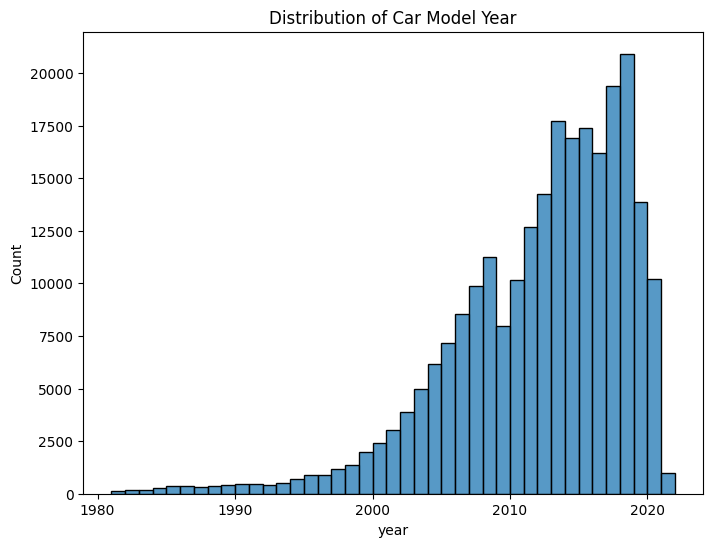

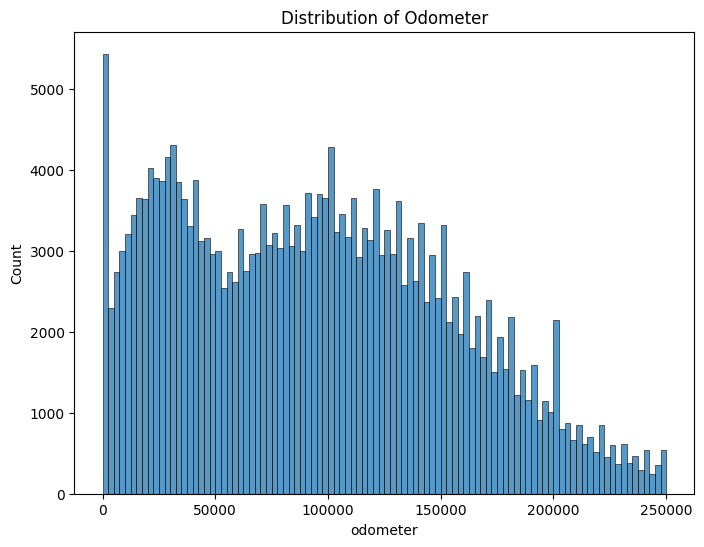

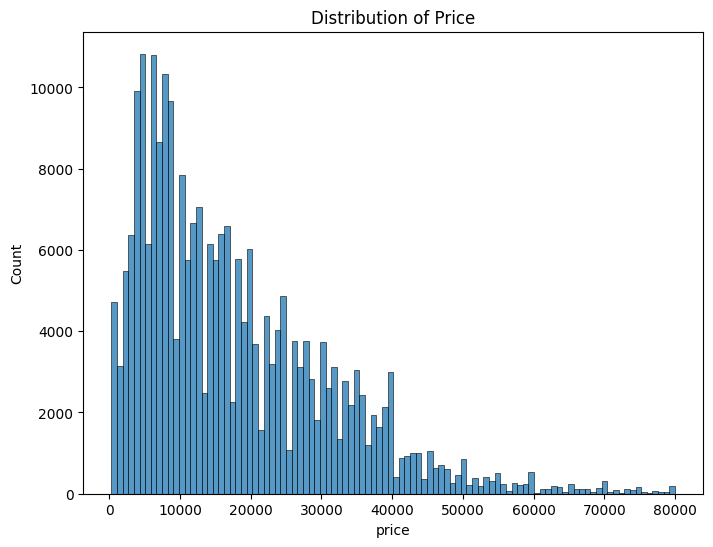

/tmp/ipykernel_223555/3023334624.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cylinders', data=df, palette='viridis')


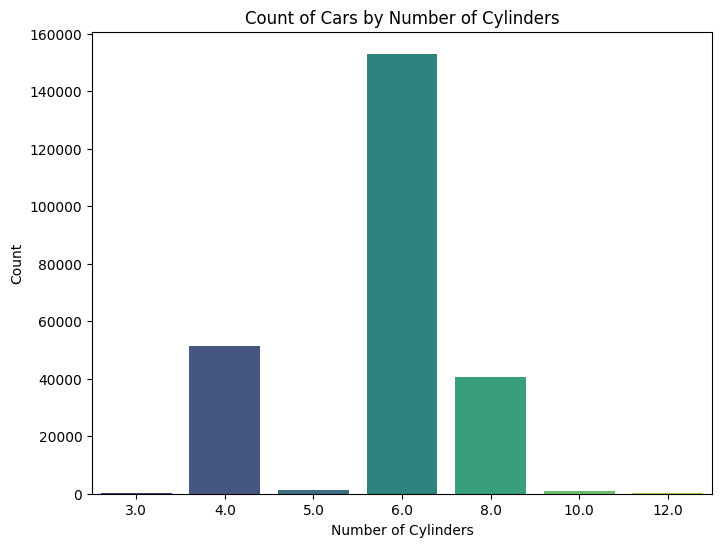

In [16]:
# --- Plot 1: Histogram for 'year' ---
# We use binwidth=1 to get a separate bar for each year.
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='year', binwidth=1)
plt.title('Distribution of Car Model Year')
plt.show()


# --- Plot 2: Histogram for 'odometer' ---
# Your plot has many bins. The default 'auto' might work,
# but setting a specific number like bins=100 gives this granular look.
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='odometer', bins=100)
plt.title('Distribution of Odometer')
plt.show()


# --- Plot 3: Histogram for 'price' ---
# This plot also has many bins, so we'll set bins=100 again.
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='price', bins=100)
plt.title('Distribution of Price')
plt.show()

# --- Plot 4: Count Plot for 'cylinders' ---
# This plot also has many bins, so we'll set bins=100 again.
plt.figure(figsize=(8, 6))
sns.countplot(x='cylinders', data=df, palette='viridis') 
plt.title('Count of Cars by Number of Cylinders')
plt.xlabel('Number of Cylinders')
plt.ylabel('Count')
plt.show()

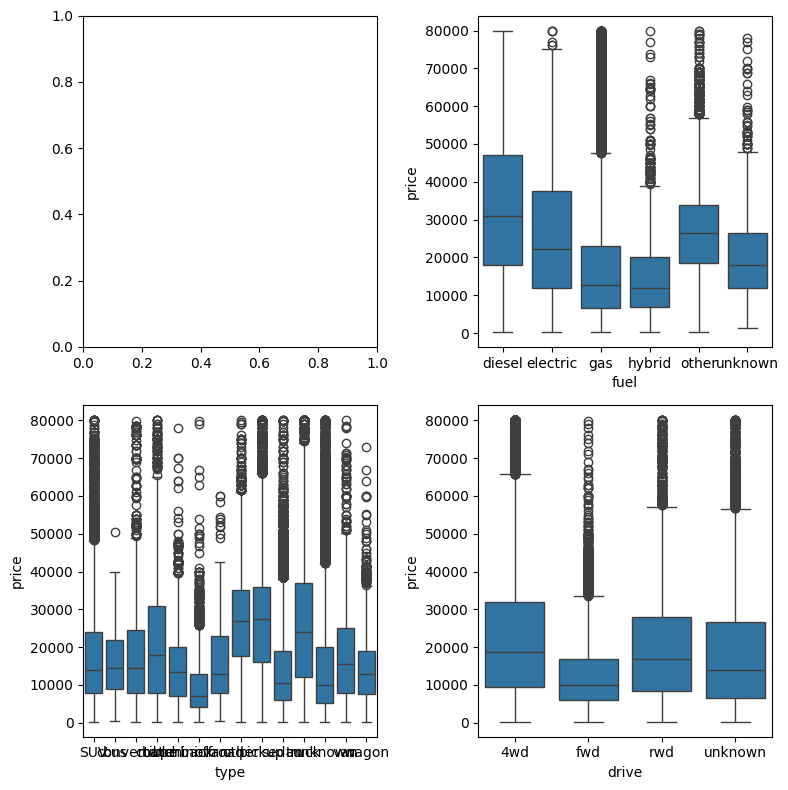

In [17]:
# Box plots for categorical variables
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
sns.boxplot(x='fuel', y='price', data=df, ax=axes[0, 1])
sns.boxplot(x='type', y='price', data=df, ax=axes[1, 0])
sns.boxplot(x='drive', y='price', data=df, ax=axes[1, 1])
plt.tight_layout()
plt.show()

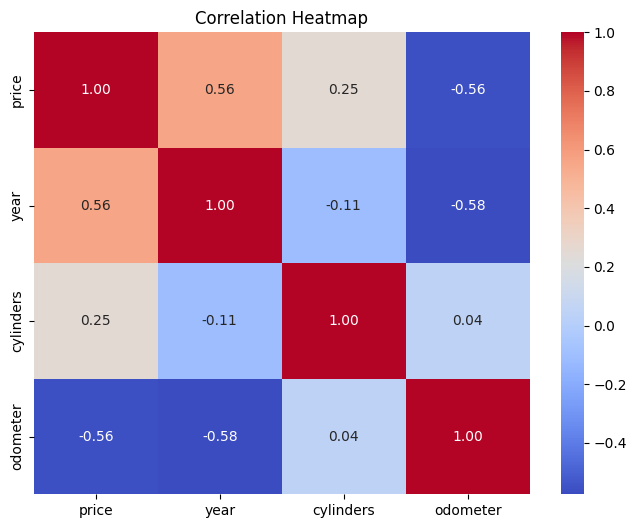

In [18]:
corr_matrix = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,    
    cmap='coolwarm',
    fmt='.2f'      
)
plt.title('Correlation Heatmap')
plt.show()

# Feature Encoding

In [ ]:

# Define the correct order, from worst to best
condition_order = ['salvage', 'fair', 'good', 'excellent', 'like new', 'new']


# Filter the list to only include categories present in your data
ordered_categories = [cat for cat in condition_order if cat in df['condition'].unique()]

# Initialize the encoder
ordinal_encoder = OrdinalEncoder(
    categories=[ordered_categories],
    handle_unknown='use_encoded_value', # Assigns a value (e.g., -1) to unknowns
    unknown_value=-1 
)

# Create the new encoded column
df['condition_encoded'] = ordinal_encoder.fit_transform(df[['condition']])

--- Ordinal Encoding for 'condition' ---
        condition  condition_encoded
140213  excellent               3.00
370208       good               2.00
346723  excellent               3.00
301829  excellent               3.00
271332       good               2.00


In [22]:

low_cardinality_cols = ['fuel', 'transmission', 'drive', 'type', 'state']

print(f"\n--- One-Hot Encoding for {low_cardinality_cols} ---")
print(f"Shape before OHE: {df.shape}")

# drop_first=True is often recommended to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=low_cardinality_cols, drop_first=True)

print(f"Shape after OHE: {df_encoded.shape}")
print("Example of new columns created:")
print(df_encoded.filter(like='drive_').head())


--- One-Hot Encoding for ['fuel', 'transmission', 'drive', 'type', 'state'] ---
Shape before OHE: (247384, 13)
Shape after OHE: (247384, 81)
Example of new columns created:
    drive_fwd  drive_rwd  drive_unknown
27      False      False           True
28      False      False           True
29      False      False           True
30      False      False           True
31      False       True          False
